<a href="https://colab.research.google.com/github/JerriWinifred/OCR/blob/main/OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install easyocr

In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

IMAGE_SIZE = [224, 224]
resnet = ResNet50(
    input_shape = IMAGE_SIZE + [3],
    weights = 'imagenet',
    include_top = False
)


caps = pd.read_csv('/content/labels.csv')
print("Shape of caps after loading:", caps.shape)


def standardize_column_names(df):
    cols = df.columns.tolist()
    label_col_name = 'label'
    if label_col_name not in cols:
        original_label_col_name = cols[0]
        df = df.rename(columns={original_label_col_name: label_col_name})
        cols[0] = label_col_name
    cols.insert(0, cols.pop(cols.index(label_col_name)))
    pixel_cols = []
    other_cols = []
    for col in cols:
        if col.startswith('pixel') and col[5:].isdigit():
            pixel_cols.append(col)
        elif col != label_col_name:
             other_cols.append(col)
    pixel_cols.sort(key=lambda x: int(x[5:]) if x[5:].isdigit() else float('inf'))
    rename_dict = {col: f'pixel{i}' for i, col in enumerate(pixel_cols)}
    df = df.rename(columns=rename_dict)
    pixel_cols = [f'pixel{i}' for i in range(len(pixel_cols))]
    new_cols_order = [label_col_name] + pixel_cols + other_cols
    for col in pixel_cols:
        if col not in df.columns:
             df[col] = np.nan
    cols_to_keep = [col for col in new_cols_order if col in df.columns]
    df = df[cols_to_keep]
    return df[new_cols_order]
caps = standardize_column_names(caps.copy())
print("Shape of caps after standardizing:", caps.shape)
all_pixel_cols = sorted(list(set(caps.columns.tolist())))
all_pixel_cols = [col for col in all_pixel_cols if col.startswith('pixel')]
all_pixel_cols.sort(key=lambda x: int(x.replace('pixel', '')))
print("All pixel columns:", all_pixel_cols)

def add_missing_pixel_cols(df, pixel_cols_list):
    current_cols = df.columns.tolist()
    for col in pixel_cols_list:
        if col not in current_cols:
            df[col] = np.nan
    new_cols_order = ['label'] + pixel_cols_list
    if 'label' not in df.columns:
      print("Warning: 'label' column not found before reordering in add_missing_pixel_cols.")
    cols_to_keep = [col for col in new_cols_order if col in df.columns]
    df = df[cols_to_keep]
    return df[new_cols_order]

caps = add_missing_pixel_cols(caps, all_pixel_cols)
print("Shape of caps after adding missing cols:", caps.shape)
combined = pd.concat([caps], ignore_index=True)
print("Shape of combined after concatenation:", combined.shape)
print("Columns in combined after concatenation:", combined.columns.tolist())
combined['label'] = combined['label'].astype(str)
combined = combined.dropna(subset=['label'])
print("Shape of combined after dropping rows with missing labels:", combined.shape)
combined = combined[combined['label'] != 'unknown'].copy()
print("Shape of combined after filtering 'unknown' labels:", combined.shape)
print("Unique labels after filtering:", combined['label'].unique())
labels = combined['label']
pixel_data_df = combined.drop('label', axis=1)
pixel_data_df = pixel_data_df[all_pixel_cols]
pixel_data_df = pixel_data_df.fillna(0)
print("Shape of pixel_data_df after imputing NaNs:", pixel_data_df.shape)
features = pixel_data_df.values.reshape(-1, 28, 28, 1).astype('float32') / 255.0
print("Shape of features after reshape:", features.shape)
unique_labels = sorted(labels.unique())
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}
encoded_labels = labels.map(label_to_index)
print("Shape of encoded_labels:", encoded_labels.shape)
print("Unique encoded labels:", sorted(encoded_labels.unique()) if not encoded_labels.empty else "Encoded labels are empty")


categorical_labels = to_categorical(encoded_labels.astype(int), num_classes=len(unique_labels))
X_train, X_test, y_train, y_test = train_test_split(features, categorical_labels, test_size=0.2, random_state=7)
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.25),
    Dense(len(unique_labels), activation='softmax')
])

early_stop = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)

model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), loss='categorical_crossentropy', metrics=['accuracy'])

sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=10),
    steps_per_epoch=len(X_train) // 64,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)
model.save("ocr_model.h5")
import pickle
with open("label_map.pkl", "wb") as f:
    pickle.dump(index_to_label, f)

Shape of caps after loading: (7, 2)
No images loaded. Model training skipped.


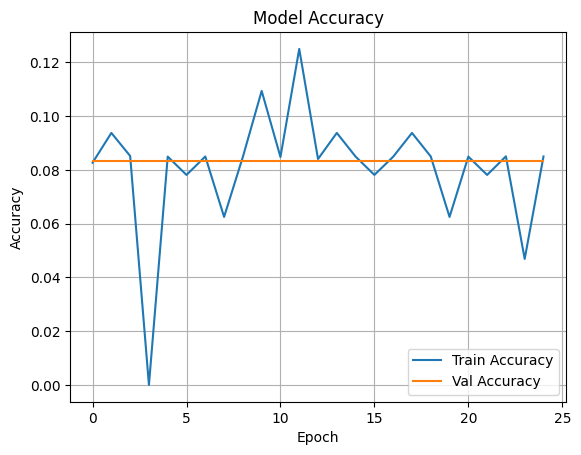

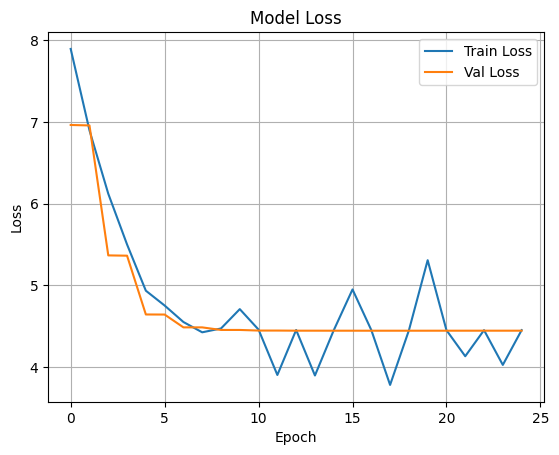

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.0849 - loss: 4.4367
Test Accuracy: 8.34%
Test Loss: 4.4453


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

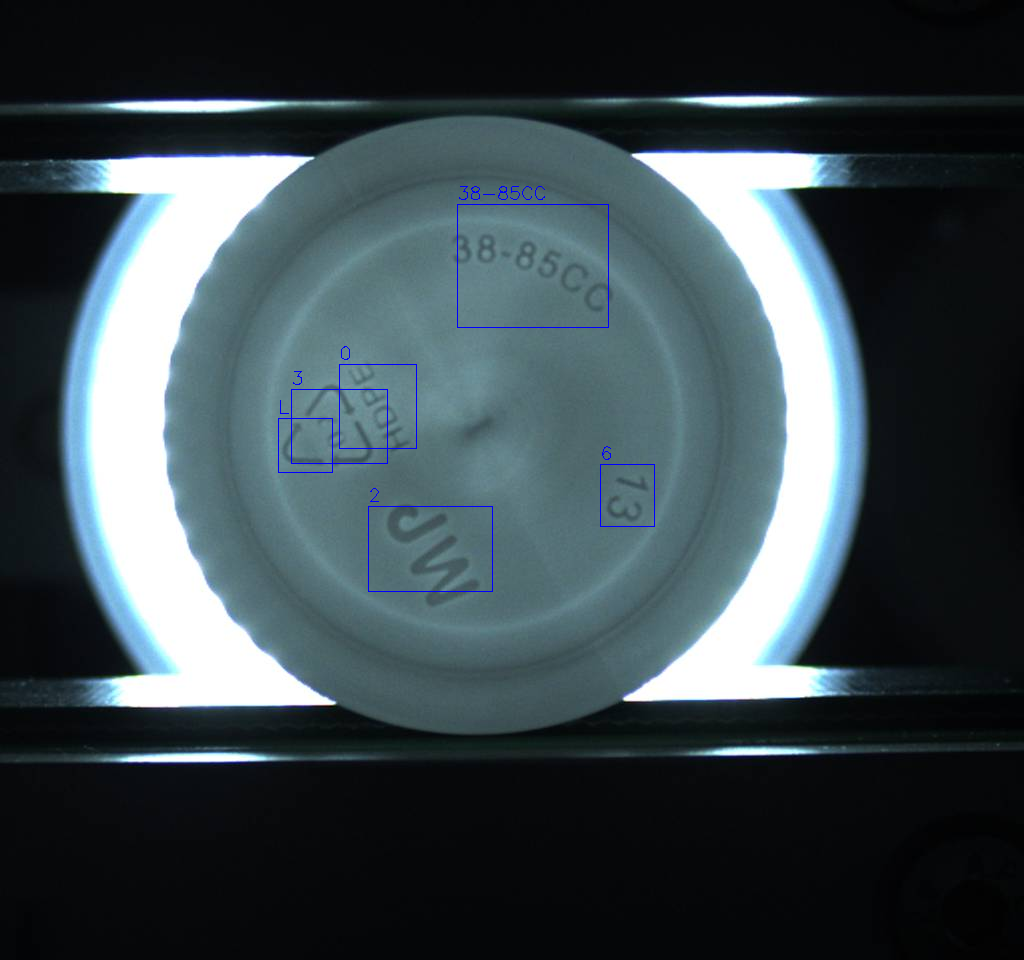

In [ ]:
from tensorflow.keras.models import load_model
import pickle
from google.colab.patches import cv2_imshow
import numpy as np
import cv2
import easyocr

model = load_model("ocr_model.h5")
with open("label_map.pkl", "rb") as f:
    index_to_label = pickle.load(f)

image = cv2.imread("/content/714_CONT1_2.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=lambda ctr: cv2.boundingRect(ctr)[0])

def preprocess_roi(roi):
    h, w = roi.shape
    scale = 20.0 / max(h, w)
    roi = cv2.resize(roi, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    padded = np.full((28, 28), 0, dtype=np.uint8)
    x_off = (28 - roi.shape[1]) // 2
    y_off = (28 - roi.shape[0]) // 2
    padded[y_off:y_off+roi.shape[0], x_off:x_off+roi.shape[1]] = roi
    return padded.astype('float32') / 255.0


reader = easyocr.Reader(['en'], gpu=False)
results = reader.readtext("/content/714_CONT1_2.jpg")

for (bbox, text, conf) in results:
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = tuple(map(int, top_left))
    bottom_right = tuple(map(int, bottom_right))
    cv2.rectangle(image, top_left, bottom_right, (255, 0, 0), 1)
    cv2.putText(image, text, (top_left[0], top_left[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 1)
cv2_imshow(image)